# Prueba de orden.

### Importación de librerías.

In [22]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, average_precision_score, classification_report
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.base import BaseEstimator, TransformerMixin

### Importación de datos.

In [13]:
df = pd.read_csv('datos_sinteticos.csv', sep=";")
df.head(2)

,cliente_id,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia,promedio,desviacion,maximo,minimo,monto_hora,moda_establecimiento,cantidad_establecimiento
0,1,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal,879.374333,602.582962,2380.04,240.25,34.208766,Farmacia,7
1,2,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal,346.078000,165.763599,762.78,63.60,16.192467,Otros,5


### Separando las variables predictoras de la objetivo.

In [14]:
X = df[['montos']]
y = df['es_anomalia']

### Separación del conjunto de prueba y entrenamiento.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=y)

### Funciones del pipeline. Aquí se realiza la permutación.

In [16]:
rng = np.random.default_rng(seed=0)
def convertir_montos(datos):

    # Se genera una serie.
    if isinstance(datos, pd.DataFrame):
        columna = datos.iloc[:, 0]
    else:
        columna = datos

    # Se separan los datos para convertirlos en listas de números.
    montos_separados = (columna.astype("string").str.strip().str.slice(1, -1).str.replace("'", "", regex=False).str.split(r",\s*", expand=True, regex=True))

    montos_array = montos_separados.to_numpy(dtype=np.float32)
    montos_permutados = rng.permutation(montos_array, axis=0)
    
    return montos_permutados

class EscaladorGlobalSecuencias(BaseEstimator, TransformerMixin):

    # Entrenador del modelo.
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=np.float32)

        self.media_ = X.mean()
        self.desviacion_ = X.std(ddof=0)

        if self.desviacion_ == 0:
            self.desviacion_ = 1.0

        return self

    # Transformador del modelo.
    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - self.media_) / self.desviacion_).astype(np.float32)

### Importación de modelo

In [17]:
pipeline_b = joblib.load("pipeline_b.joblib")
modelo_B = load_model("modelo_b.keras")

### Aplicando preprocesamiento.

In [18]:
X_test_b = pipeline_b.transform(X_test)

### Predicción de la probabilidad.

In [19]:
y_prob_test_b = modelo_B.predict(X_test_b, batch_size=32, verbose=0).ravel()

### Matriz de confusión.

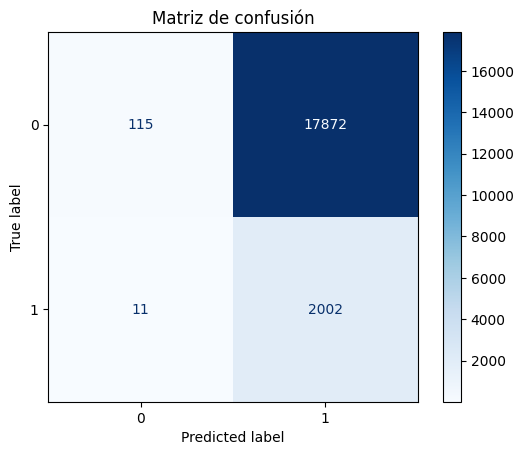

In [20]:
y_pred_optimo_b = (y_prob_test_b >= 0.2937).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimo_b, cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

### Métricas del conjunto de entrenamiento.

In [23]:
print('Reporte de clasificación')
print(classification_report(y_test, y_pred_optimo_b))
pr_auc = average_precision_score(y_test, y_prob_test_b)
print(f"PR-AUC en prueba: {pr_auc:.4f}")

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.91      0.01      0.01     17987
           1       0.10      0.99      0.18      2013

    accuracy                           0.11     20000
   macro avg       0.51      0.50      0.10     20000
weighted avg       0.83      0.11      0.03     20000

PR-AUC en prueba: 0.1039
